# Lab 4 – Greedy Algorithms


## Bài 1 – Greedy cơ bản


### Hàm 1 – Activity Selection (Chọn hoạt động tối đa)

In [1]:
def activity_selection(activities):
    """
    Chọn số lượng hoạt động tối đa không chồng lấp.
    
    Chiến lược Greedy: Chọn kết thúc sớm nhất (earliest finish time)
    - Hoạt động kết thúc sớm → giải phóng thời gian sớm → còn nhiều thời gian cho các hoạt động sau.
    - Đã chứng minh tối ưu bằng exchange argument.
    
    Độ phức tạp:
        - Sort: O(n log n)
        - Loop: O(n)
        - Tổng: O(n log n)
        - Không gian: O(1) nếu không tính output
    
    Input: activities = [(start, finish), ...]
    Output: list của các hoạt động được chọn
    """
    if not activities:
        return []
    
    # Bước 1: Sort theo finish time (thời gian kết thúc)
    activities.sort(key=lambda x: x[1])
    
    # Bước 2: Chọn hoạt động đầu tiên (kết thúc sớm nhất)
    selected = [activities[0]]
    last_finish = activities[0][1]
    
    # Bước 3: Duyệt các hoạt động còn lại
    for i in range(1, len(activities)):
        start, finish = activities[i]
        
        # Nếu không xung đột (start >= last_finish) → chọn
        if start >= last_finish:
            selected.append((start, finish))
            last_finish = finish
    
    return selected

In [2]:
# ===== Test Activity Selection =====
print("=== Test Activity Selection ===")

# Test case 1
activities1 = [
    (1, 4),   # A1
    (3, 5),   # A2
    (0, 6),   # A3
    (5, 7),   # A4
    (3, 9),   # A5
    (5, 9),   # A6
    (6, 10),  # A7
    (8, 11),  # A8
    (8, 12),  # A9
    (2, 14),  # A10
    (12, 16)  # A11
]

result1 = activity_selection(activities1)
print(f"Hoạt động được chọn: {result1}")
print(f"Số lượng: {len(result1)}")  # Kỳ vọng: 4

# Test case 2
activities2 = [
    (1, 3),
    (2, 4),
    (3, 5),
    (4, 6)
]

result2 = activity_selection(activities2)
print(f"\nHoạt động được chọn: {result2}")
print(f"Số lượng: {len(result2)}")  # Kỳ vọng: 2

=== Test Activity Selection ===
Hoạt động được chọn: [(1, 4), (5, 7), (8, 11), (12, 16)]
Số lượng: 4

Hoạt động được chọn: [(1, 3), (3, 5)]
Số lượng: 2


**Giải thích:**
- **Sort**: O(n log n) – Sắp xếp theo finish time
- **Loop**: O(n) – Duyệt 1 lần qua các hoạt động
- **Tổng**: O(n log n)
- **Tại sao đúng**: Chọn kết thúc sớm nhất luôn an toàn (chứng minh bằng exchange argument). Không bao giờ làm mất lời giải tối ưu.

### Hàm 2 – Coin Change Greedy (Đổi tiền tham lam)

In [3]:
def coin_change_greedy(amount, coins):
    """
    Đổi tiền bằng số xu ít nhất (Greedy approach).
    
    Chiến lược Greedy: Luôn chọn mệnh giá lớn nhất có thể
    - Xu lớn nhất → giảm amount nhanh nhất.
    
    LƯU Ý: Chỉ đúng với hệ tiền chuẩn (canonical coin system)!
    
    Độ phức tạp:
        - Sort: O(n log n)
        - Loop: O(amount / min_coin) worst case
        - Thực tế: O(n log n) vì số mệnh giá nhỏ
    
    Input: amount (số tiền), coins (list mệnh giá)
    Output: (số xu ít nhất, list chi tiết các xu), hoặc (-1, []) nếu không đổi được
    """
    # Bước 1: Sort giảm dần (lớn nhất trước)
    coins_sorted = sorted(coins, reverse=True)
    count = 0
    result = []  # Lưu chi tiết các xu đã dùng
    remaining = amount
    
    # Bước 2: Duyệt từng mệnh giá
    for coin in coins_sorted:
        # Lấy nhiều nhất có thể từ mệnh giá này
        while remaining >= coin:
            result.append(coin)
            remaining -= coin
            count += 1
    
    # Bước 3: Kiểm tra kết quả
    if remaining == 0:
        return count, result
    else:
        return -1, []  # Không đổi được

In [4]:
# ===== Test Coin Change Greedy =====
print("\n=== Test Coin Change Greedy ===")

# Test case 1: Hệ tiền chuẩn (Greedy ĐÚNG)
print("Test 1: Hệ tiền chuẩn [25, 10, 5, 1]")
amount1 = 63
coins1 = [25, 10, 5, 1]
count1, result1 = coin_change_greedy(amount1, coins1)
print(f"Số tiền: {amount1}")
print(f"Số xu: {count1}")
print(f"Chi tiết: {result1}")
# Kỳ vọng: 6 xu [25, 25, 10, 1, 1, 1]

# Test case 2: Hệ tiền chuẩn khác
print("\nTest 2: Hệ tiền VN [500, 200, 100, 50, 20, 10]")
amount2 = 370
coins2 = [500, 200, 100, 50, 20, 10]
count2, result2 = coin_change_greedy(amount2, coins2)
print(f"Số tiền: {amount2}")
print(f"Số xu: {count2}")
print(f"Chi tiết: {result2}")
# Kỳ vọng: 4 xu [200, 100, 50, 20]

# Test case 3: Hệ mệnh giá lạ (Greedy SAI!)
print("\nTest 3: Hệ mệnh giá lạ [25, 10, 1]")
amount3 = 30
coins3 = [25, 10, 1]
count3, result3 = coin_change_greedy(amount3, coins3)
print(f"Số tiền: {amount3}")
print(f"Số xu: {count3}")
print(f"Chi tiết: {result3}")
print("⚠️  CHÚ Ý: Greedy cho 6 xu [25,1,1,1,1,1]")
print("    Nhưng tối ưu là 3 xu [10,10,10]!")
print("    → Greedy SAI với hệ mệnh giá này!")


=== Test Coin Change Greedy ===
Test 1: Hệ tiền chuẩn [25, 10, 5, 1]
Số tiền: 63
Số xu: 6
Chi tiết: [25, 25, 10, 1, 1, 1]

Test 2: Hệ tiền VN [500, 200, 100, 50, 20, 10]
Số tiền: 370
Số xu: 4
Chi tiết: [200, 100, 50, 20]

Test 3: Hệ mệnh giá lạ [25, 10, 1]
Số tiền: 30
Số xu: 6
Chi tiết: [25, 1, 1, 1, 1, 1]
⚠️  CHÚ Ý: Greedy cho 6 xu [25,1,1,1,1,1]
    Nhưng tối ưu là 3 xu [10,10,10]!
    → Greedy SAI với hệ mệnh giá này!


**Giải thích:**
- **Khi nào Greedy đúng**: Hệ tiền chuẩn (USD, VNĐ) – mỗi mệnh giá là bội của mệnh giá nhỏ hơn.
- **Khi nào Greedy sai**: Hệ mệnh giá tùy ý – cần dùng Dynamic Programming.

### Hàm 3 – Fractional Knapsack (Ba lô phân số)

In [5]:
def fractional_knapsack(capacity, items):
    """
    Bài toán Ba lô phân số (Fractional Knapsack).
    
    Chiến lược Greedy: Chọn vật có value/weight (ratio) cao nhất trước
    - Vì có thể lấy phân số → chọn ratio cao nhất luôn tối ưu.
    - Khác với 0/1 Knapsack: không bị ràng buộc lấy nguyên vật.
    
    Độ phức tạp:
        - Tính ratio: O(n)
        - Sort: O(n log n)
        - Loop: O(n)
        - Tổng: O(n log n)
    
    Input:
        capacity: sức chứa ba lô
        items: [(weight, value), ...]
    Output: (giá trị tối đa, chi tiết các vật đã chọn)
    """
    # Bước 1: Tính ratio (value/weight) cho mỗi vật và sort giảm dần
    items_with_ratio = []
    for weight, value in items:
        ratio = value / weight
        items_with_ratio.append((weight, value, ratio))
    
    # Sort theo ratio giảm dần
    items_with_ratio.sort(key=lambda x: x[2], reverse=True)
    
    # Bước 2: Duyệt và chọn
    total_value = 0.0
    remaining_capacity = capacity
    result = []  # Lưu chi tiết các vật đã chọn
    
    for weight, value, ratio in items_with_ratio:
        if remaining_capacity == 0:
            break
        
        # Nếu vật nhẹ hơn sức chứa còn lại → lấy hết
        if weight <= remaining_capacity:
            total_value += value
            remaining_capacity -= weight
            result.append((weight, value, 1.0))  # Lấy 100%
        else:
            # Lấy một phần của vật
            fraction = remaining_capacity / weight
            total_value += value * fraction
            result.append((weight, value, fraction))
            remaining_capacity = 0
    
    return total_value, result

In [6]:
# ===== Test Fractional Knapsack =====
print("\n=== Test Fractional Knapsack ===")

# Test case 1
capacity1 = 50
items1 = [
    (10, 60),  # ratio = 6.0
    (20, 100), # ratio = 5.0
    (30, 120)  # ratio = 4.0
]

total1, result1 = fractional_knapsack(capacity1, items1)
print(f"Sức chứa: {capacity1}")
print(f"Giá trị tối đa: {total1}")
print(f"Chi tiết:")
for weight, value, fraction in result1:
    print(f"  Vật (w={weight}, v={value}): Lấy {fraction*100:.1f}%")
# Kỳ vọng: 240 (lấy hết vật 1 và 2, lấy 2/3 vật 3)

# Test case 2
capacity2 = 60
items2 = [
    (10, 500),  # ratio = 50
    (20, 300),  # ratio = 15
    (30, 400)   # ratio = 13.33
]

total2, result2 = fractional_knapsack(capacity2, items2)
print(f"\nSức chứa: {capacity2}")
print(f"Giá trị tối đa: {total2}")
print(f"Chi tiết:")
for weight, value, fraction in result2:
    print(f"  Vật (w={weight}, v={value}): Lấy {fraction*100:.1f}%")


=== Test Fractional Knapsack ===
Sức chứa: 50
Giá trị tối đa: 240.0
Chi tiết:
  Vật (w=10, v=60): Lấy 100.0%
  Vật (w=20, v=100): Lấy 100.0%
  Vật (w=30, v=120): Lấy 66.7%

Sức chứa: 60
Giá trị tối đa: 1200.0
Chi tiết:
  Vật (w=10, v=500): Lấy 100.0%
  Vật (w=20, v=300): Lấy 100.0%
  Vật (w=30, v=400): Lấy 100.0%


**Giải thích:**
- **Tại sao Greedy đúng**: Vì có thể lấy phân số → chọn ratio cao nhất luôn tối ưu.
- **So sánh với 0/1 Knapsack**:
  - 0/1 Knapsack: Phải lấy nguyên vật → Greedy **SAI**, phải dùng DP.
  - Fractional: Lấy được phân số → Greedy **ĐÚNG**!

### Hàm 4 – Minimum Number of Intervals to Remove

In [7]:
def min_intervals_remove(intervals):
    """
    Tìm số khoảng thời gian ít nhất cần xóa để còn lại không chồng lấp.
    
    Chiến lược Greedy: Tái sử dụng Activity Selection!
    - Tìm số khoảng tối đa giữ lại (activity_selection)
    - Số cần xóa = tổng - số giữ lại
    - Pattern: Maximize keep → Minimize remove
    
    Độ phức tạp: O(n log n) (do activity_selection)
    
    Input: intervals = [(start, end), ...]
    Output: Số khoảng ít nhất cần xóa
    """
    if not intervals:
        return 0
    
    # Tái sử dụng hàm activity_selection
    max_keep = activity_selection(intervals[:])
    
    # Số cần xóa
    num_remove = len(intervals) - len(max_keep)
    
    return num_remove

In [8]:
# ===== Test Minimum Intervals Remove =====
print("\n=== Test Minimum Intervals Remove ===")

# Test case 1
intervals1 = [
    (1, 2),
    (2, 3),
    (3, 4),
    (1, 3)
]

result1 = min_intervals_remove(intervals1)
print(f"Intervals: {intervals1}")
print(f"Số khoảng cần xóa: {result1}")
print(f"Giải thích: Có thể giữ 3 khoảng [1,2], [2,3], [3,4]")
print(f"           → Xóa 1 khoảng [1,3]")
# Kỳ vọng: 1

# Test case 2
intervals2 = [
    (1, 2),
    (1, 2),
    (1, 2)
]

result2 = min_intervals_remove(intervals2)
print(f"\nIntervals: {intervals2}")
print(f"Số khoảng cần xóa: {result2}")
print(f"Giải thích: Chỉ giữ được 1 khoảng → xóa 2")
# Kỳ vọng: 2

# Test case 3
intervals3 = [
    (1, 100),
    (11, 22),
    (1, 11),
    (2, 12)
]

result3 = min_intervals_remove(intervals3)
print(f"\nIntervals: {intervals3}")
print(f"Số khoảng cần xóa: {result3}")
# Kỳ vọng: 2


=== Test Minimum Intervals Remove ===
Intervals: [(1, 2), (2, 3), (3, 4), (1, 3)]
Số khoảng cần xóa: 1
Giải thích: Có thể giữ 3 khoảng [1,2], [2,3], [3,4]
           → Xóa 1 khoảng [1,3]

Intervals: [(1, 2), (1, 2), (1, 2)]
Số khoảng cần xóa: 2
Giải thích: Chỉ giữ được 1 khoảng → xóa 2

Intervals: [(1, 100), (11, 22), (1, 11), (2, 12)]
Số khoảng cần xóa: 2


---
## Bài 2 – Meeting Rooms và So sánh
Cài đặt bài toán phức tạp hơn với **Heap** và so sánh **Greedy vs DP**.

### Phần A – Minimum Meeting Rooms

In [9]:
import heapq
import time


def min_meeting_rooms(meetings):
    """
    Tìm số phòng họp tối thiểu cần thiết.
    
    Chiến lược Greedy: Sort theo start time + dùng Heap theo dõi end time
    - Heap (min-heap) lưu end time của các phòng đang dùng.
    - Nếu meeting mới bắt đầu sau khi phòng sớm nhất kết thúc → tái sử dụng phòng.
    - Ngược lại → cần phòng mới.
    
    Tại sao dùng Heap:
    - Heap cho phép lấy phòng kết thúc sớm nhất trong O(log n).
    - Nếu dùng list, phải duyệt O(n) để tìm phòng trống → chậm hơn.
    
    Độ phức tạp:
        - Sort: O(n log n)
        - Loop + Heap ops: O(n log n)
        - Tổng: O(n log n)
    
    Input: meetings = [(start, end), ...]
    Output: số phòng tối thiểu
    """
    if not meetings:
        return 0
    
    # Sort meetings theo start time
    meetings.sort(key=lambda x: x[0])
    
    # Heap lưu end time của các phòng đang dùng
    heap = []
    
    # Thêm meeting đầu tiên vào heap
    heapq.heappush(heap, meetings[0][1])
    
    # Duyệt các meetings còn lại
    for i in range(1, len(meetings)):
        start, end = meetings[i]
        
        # Nếu meeting bắt đầu SAU khi phòng sớm nhất kết thúc
        # → Tái sử dụng phòng (pop phòng cũ)
        if start >= heap[0]:
            heapq.heappop(heap)
        
        # Thêm meeting hiện tại (dùng phòng mới hoặc tái sử dụng)
        heapq.heappush(heap, end)
    
    # Số phòng = kích thước heap
    return len(heap)

In [10]:
# ===== Test Minimum Meeting Rooms =====
print("\n=== Test Minimum Meeting Rooms ===")

# Test case 1: Các meeting chồng lấp
meetings1 = [(0, 30), (5, 10), (15, 20)]
result1 = min_meeting_rooms(meetings1)
print(f"Meetings: {meetings1}")
print(f"Số phòng tối thiểu: {result1}")
# Kỳ vọng: 2 (meeting 1 chồng với meeting 2)

# Test case 2: Không chồng lấp
meetings2 = [(1, 5), (5, 10), (10, 15)]
result2 = min_meeting_rooms(meetings2)
print(f"\nMeetings: {meetings2}")
print(f"Số phòng tối thiểu: {result2}")
# Kỳ vọng: 1

# Test case 3: Tất cả chồng lấp
meetings3 = [(1, 10), (2, 7), (3, 19), (8, 12), (10, 20), (11, 30)]
result3 = min_meeting_rooms(meetings3)
print(f"\nMeetings: {meetings3}")
print(f"Số phòng tối thiểu: {result3}")
# Kỳ vọng: 4


=== Test Minimum Meeting Rooms ===
Meetings: [(0, 30), (5, 10), (15, 20)]
Số phòng tối thiểu: 2

Meetings: [(1, 5), (5, 10), (10, 15)]
Số phòng tối thiểu: 1

Meetings: [(1, 10), (2, 7), (3, 19), (8, 12), (10, 20), (11, 30)]
Số phòng tối thiểu: 4


**Giải thích tại sao dùng Heap:**
- Min-heap giúp nhanh chóng tìm phòng kết thúc sớm nhất trong O(log n).
- Nếu dùng list thường, phải duyệt O(n) để tìm phòng trống.
- Heap giúp tổng thời gian là O(n log n) thay vì O(n²).

### Phần B – Coin Change với Dynamic Programming

In [11]:
def coin_change_dp(amount, coins):
    """
    Coin Change với Dynamic Programming.
    Luôn cho lời giải tối ưu.
    
    dp[i] = số xu ít nhất để đổi số tiền i
    dp[i] = min(dp[i - coin] + 1) với mọi coin <= i
    
    Độ phức tạp:
        - Thời gian: O(amount * len(coins))
        - Không gian: O(amount)
    
    Input: amount (số tiền), coins (list mệnh giá)
    Output: số xu ít nhất, hoặc -1 nếu không đổi được
    """
    # Khởi tạo dp array
    dp = [float('inf')] * (amount + 1)
    dp[0] = 0  # Base case: 0 đồng cần 0 xu
    
    # Tính dp[i] cho i từ 1 đến amount
    for i in range(1, amount + 1):
        for coin in coins:
            if coin <= i:
                dp[i] = min(dp[i], dp[i - coin] + 1)
    
    # Trả về kết quả
    if dp[amount] == float('inf'):
        return -1
    return dp[amount]

In [12]:
# ===== Test Coin Change DP =====
print("\n=== Test Coin Change DP ===")

# Test với hệ mệnh giá lạ
print("Test: Hệ mệnh giá lạ [25, 10, 1], amount = 30")
dp_result = coin_change_dp(30, [25, 10, 1])
greedy_count, greedy_detail = coin_change_greedy(30, [25, 10, 1])
print(f"DP result: {dp_result} xu (tối ưu: [10, 10, 10])")
print(f"Greedy result: {greedy_count} xu → {greedy_detail}")
print(f"→ DP cho kết quả tối ưu, Greedy SAI!")

# Test với hệ tiền chuẩn
print("\nTest: Hệ tiền chuẩn [25, 10, 5, 1], amount = 63")
dp_result2 = coin_change_dp(63, [25, 10, 5, 1])
greedy_count2, greedy_detail2 = coin_change_greedy(63, [25, 10, 5, 1])
print(f"DP result: {dp_result2} xu")
print(f"Greedy result: {greedy_count2} xu → {greedy_detail2}")
print(f"→ Cả hai cho kết quả giống nhau!")


=== Test Coin Change DP ===
Test: Hệ mệnh giá lạ [25, 10, 1], amount = 30
DP result: 3 xu (tối ưu: [10, 10, 10])
Greedy result: 6 xu → [25, 1, 1, 1, 1, 1]
→ DP cho kết quả tối ưu, Greedy SAI!

Test: Hệ tiền chuẩn [25, 10, 5, 1], amount = 63
DP result: 6 xu
Greedy result: 6 xu → [25, 25, 10, 1, 1, 1]
→ Cả hai cho kết quả giống nhau!


### Phần C – So sánh hiệu suất Greedy vs DP

In [13]:
def compare_coin_change(amount, coins):
    """So sánh Greedy vs DP cho bài toán Coin Change."""
    print(f"\n{'='*60}")
    print(f"So sánh Coin Change: amount={amount}, coins={coins}")
    print(f"{'='*60}")
    
    # Test Greedy
    print("\n[1] GREEDY:")
    start = time.time()
    greedy_result, greedy_detail = coin_change_greedy(amount, coins[:])
    greedy_time = time.time() - start
    print(f"Kết quả: {greedy_result} xu")
    print(f"Chi tiết: {greedy_detail}")
    print(f"Thời gian: {greedy_time:.6f}s")
    
    # Test DP
    print("\n[2] DYNAMIC PROGRAMMING:")
    start = time.time()
    dp_result = coin_change_dp(amount, coins)
    dp_time = time.time() - start
    print(f"Kết quả: {dp_result} xu")
    print(f"Thời gian: {dp_time:.6f}s")
    
    # So sánh
    print("\n[3] SO SÁNH:")
    if greedy_result == dp_result:
        print("✅ Greedy ĐÚNG - cho kết quả tối ưu!")
    elif greedy_result == -1:
        print(f"❌ Greedy KHÔNG đổi được, DP cho {dp_result} xu!")
    else:
        print(f"❌ Greedy SAI - Greedy: {greedy_result} xu, DP: {dp_result} xu (kém hơn {greedy_result - dp_result} xu)!")
    
    if greedy_time > 0:
        print(f"Tốc độ: Greedy nhanh hơn {dp_time/greedy_time:.2f}x")
    else:
        print(f"Tốc độ: Greedy nhanh hơn (quá nhanh để đo)")

In [14]:
# Test với hệ tiền chuẩn
compare_coin_change(67, [25, 10, 5, 1])

# Test với hệ mệnh giá lạ
compare_coin_change(30, [25, 10, 1])


So sánh Coin Change: amount=67, coins=[25, 10, 5, 1]

[1] GREEDY:
Kết quả: 6 xu
Chi tiết: [25, 25, 10, 5, 1, 1]
Thời gian: 0.000000s

[2] DYNAMIC PROGRAMMING:
Kết quả: 6 xu
Thời gian: 0.000000s

[3] SO SÁNH:
✅ Greedy ĐÚNG - cho kết quả tối ưu!
Tốc độ: Greedy nhanh hơn (quá nhanh để đo)

So sánh Coin Change: amount=30, coins=[25, 10, 1]

[1] GREEDY:
Kết quả: 6 xu
Chi tiết: [25, 1, 1, 1, 1, 1]
Thời gian: 0.000000s

[2] DYNAMIC PROGRAMMING:
Kết quả: 3 xu
Thời gian: 0.000000s

[3] SO SÁNH:
❌ Greedy SAI - Greedy: 6 xu, DP: 3 xu (kém hơn 3 xu)!
Tốc độ: Greedy nhanh hơn (quá nhanh để đo)


---
## Bài 3 – Matching Problems
Cài đặt các bài toán ghép cặp và tối ưu hóa.

### Phần A – Assign Cookies (LeetCode 455)

In [15]:
def find_content_children(greed, cookies):
    """
    Assign Cookies - LeetCode 455
    Tìm số trẻ tối đa có thể thỏa mãn.
    
    Chiến lược Greedy: Sort cả 2 mảng + Two Pointers
    - Sort greed (độ tham) và cookies (kích thước bánh) tăng dần.
    - Dùng 2 con trỏ: nếu cookie đủ lớn cho trẻ → thỏa mãn, tiến cả 2.
    - Nếu cookie nhỏ hơn → bỏ qua cookie đó, thử cookie lớn hơn.
    
    Độ phức tạp:
        - Sort: O(n log n + m log m)
        - Loop: O(n + m)
        - Tổng: O(n log n + m log m)
    
    Input:
        greed: list[int] – độ tham của mỗi trẻ
        cookies: list[int] – kích thước mỗi bánh
    Output: số trẻ tối đa được thỏa mãn
    """
    # Sort cả greed và cookies tăng dần
    greed.sort()
    cookies.sort()
    
    # Dùng 2 con trỏ duyệt
    child = 0  # Con trỏ cho trẻ
    cookie = 0  # Con trỏ cho bánh
    satisfied = 0  # Số trẻ đã thỏa mãn
    
    while child < len(greed) and cookie < len(cookies):
        # Nếu cookie đủ lớn cho trẻ
        if cookies[cookie] >= greed[child]:
            satisfied += 1
            child += 1  # Tiến đến trẻ tiếp theo
        # Luôn tiến cookie (dù đã dùng hay bỏ qua)
        cookie += 1
    
    return satisfied

In [16]:
# ===== Test Assign Cookies =====
print("\n=== Test Assign Cookies ===")

# Test case 1
greed1 = [1, 2, 3]
cookies1 = [1, 1]
result1 = find_content_children(greed1[:], cookies1[:])
print(f"Greed: {greed1}, Cookies: {cookies1}")
print(f"Số trẻ thỏa mãn: {result1}")
# Kỳ vọng: 1 (chỉ trẻ có greed=1 được thỏa mãn)

# Test case 2
greed2 = [1, 2]
cookies2 = [1, 2, 3]
result2 = find_content_children(greed2[:], cookies2[:])
print(f"\nGreed: {greed2}, Cookies: {cookies2}")
print(f"Số trẻ thỏa mãn: {result2}")
# Kỳ vọng: 2

# Test case 3
greed3 = [10, 9, 8, 7]
cookies3 = [5, 6, 7, 8]
result3 = find_content_children(greed3[:], cookies3[:])
print(f"\nGreed: {greed3}, Cookies: {cookies3}")
print(f"Số trẻ thỏa mãn: {result3}")
# Kỳ vọng: 2 (trẻ greed=7 nhận cookie=7, trẻ greed=8 nhận cookie=8)


=== Test Assign Cookies ===
Greed: [1, 2, 3], Cookies: [1, 1]
Số trẻ thỏa mãn: 1

Greed: [1, 2], Cookies: [1, 2, 3]
Số trẻ thỏa mãn: 2

Greed: [10, 9, 8, 7], Cookies: [5, 6, 7, 8]
Số trẻ thỏa mãn: 2


### Phần B – Assign Bikes

In [17]:
def manhattan_distance(p1, p2):
    """Tính khoảng cách Manhattan giữa 2 điểm."""
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def assign_bikes(workers, bikes):
    """
    Ghép mỗi worker với 1 bike sao cho tổng khoảng cách Manhattan nhỏ nhất.
    
    Chiến lược Greedy:
    1. Tính tất cả khoảng cách Manhattan giữa mọi cặp (worker, bike)
    2. Sort theo khoảng cách tăng dần
    3. Greedy chọn cặp gần nhất chưa dùng
    
    LƯU Ý: Greedy không luôn cho kết quả tối ưu tuyệt đối,
    nhưng cho kết quả tốt trong thực tế.
    
    Độ phức tạp:
        - Tính khoảng cách: O(W * B)
        - Sort: O(W * B * log(W * B))
        - Loop: O(W * B)
    
    Input:
        workers: [(x, y), ...] – vị trí các worker
        bikes: [(x, y), ...] – vị trí các bike
    Output: list các cặp (worker_idx, bike_idx, distance)
    """
    # Bước 1: Tính tất cả khoảng cách
    distances = []
    for i, worker in enumerate(workers):
        for j, bike in enumerate(bikes):
            dist = manhattan_distance(worker, bike)
            distances.append((dist, i, j))  # (distance, worker_idx, bike_idx)
    
    # Bước 2: Sort theo khoảng cách tăng dần
    distances.sort()
    
    # Bước 3: Greedy chọn cặp gần nhất chưa dùng
    assigned_workers = set()
    assigned_bikes = set()
    result = []
    total_distance = 0
    
    for dist, w_idx, b_idx in distances:
        if w_idx not in assigned_workers and b_idx not in assigned_bikes:
            result.append((w_idx, b_idx, dist))
            assigned_workers.add(w_idx)
            assigned_bikes.add(b_idx)
            total_distance += dist
        
        # Dừng khi tất cả worker đã được ghép
        if len(assigned_workers) == len(workers):
            break
    
    return result, total_distance

In [18]:
# ===== Test Assign Bikes =====
print("\n=== Test Assign Bikes ===")

# Test case 1
workers1 = [(0, 0), (2, 1)]
bikes1 = [(1, 2), (3, 3)]

result1, total1 = assign_bikes(workers1, bikes1)
print(f"Workers: {workers1}")
print(f"Bikes: {bikes1}")
print(f"Ghép cặp:")
for w_idx, b_idx, dist in result1:
    print(f"  Worker {w_idx} {workers1[w_idx]} → Bike {b_idx} {bikes1[b_idx]}: distance = {dist}")
print(f"Tổng khoảng cách: {total1}")

# Test case 2
workers2 = [(0, 0), (1, 1), (2, 0)]
bikes2 = [(1, 0), (10, 10), (0, 1)]

result2, total2 = assign_bikes(workers2, bikes2)
print(f"\nWorkers: {workers2}")
print(f"Bikes: {bikes2}")
print(f"Ghép cặp:")
for w_idx, b_idx, dist in result2:
    print(f"  Worker {w_idx} {workers2[w_idx]} → Bike {b_idx} {bikes2[b_idx]}: distance = {dist}")
print(f"Tổng khoảng cách: {total2}")


=== Test Assign Bikes ===
Workers: [(0, 0), (2, 1)]
Bikes: [(1, 2), (3, 3)]
Ghép cặp:
  Worker 1 (2, 1) → Bike 0 (1, 2): distance = 2
  Worker 0 (0, 0) → Bike 1 (3, 3): distance = 6
Tổng khoảng cách: 8

Workers: [(0, 0), (1, 1), (2, 0)]
Bikes: [(1, 0), (10, 10), (0, 1)]
Ghép cặp:
  Worker 0 (0, 0) → Bike 0 (1, 0): distance = 1
  Worker 1 (1, 1) → Bike 2 (0, 1): distance = 1
  Worker 2 (2, 0) → Bike 1 (10, 10): distance = 18
Tổng khoảng cách: 20


### Phần C – Performance Analysis

In [19]:
import random
import matplotlib.pyplot as plt


def generate_test_data(n):
    """Tạo dữ liệu test ngẫu nhiên cho Activity Selection."""
    activities = []
    for i in range(n):
        start = random.randint(0, 100)
        duration = random.randint(1, 20)
        end = start + duration
        activities.append((start, end))
    return activities


def benchmark_activity_selection(sizes):
    """Đo thời gian Activity Selection với các kích thước input khác nhau."""
    times = []
    for size in sizes:
        activities = generate_test_data(size)
        
        start = time.time()
        activity_selection(activities)
        elapsed = time.time() - start
        times.append(elapsed)
        print(f"n={size:>6}: {elapsed:.6f}s")
    return times

In [20]:
# Benchmark
print("=== Benchmark Activity Selection ===")
sizes = [100, 500, 1000, 5000, 10000]
times = benchmark_activity_selection(sizes)

=== Benchmark Activity Selection ===
n=   100: 0.000000s
n=   500: 0.000000s
n=  1000: 0.000000s
n=  5000: 0.000000s
n= 10000: 0.003266s


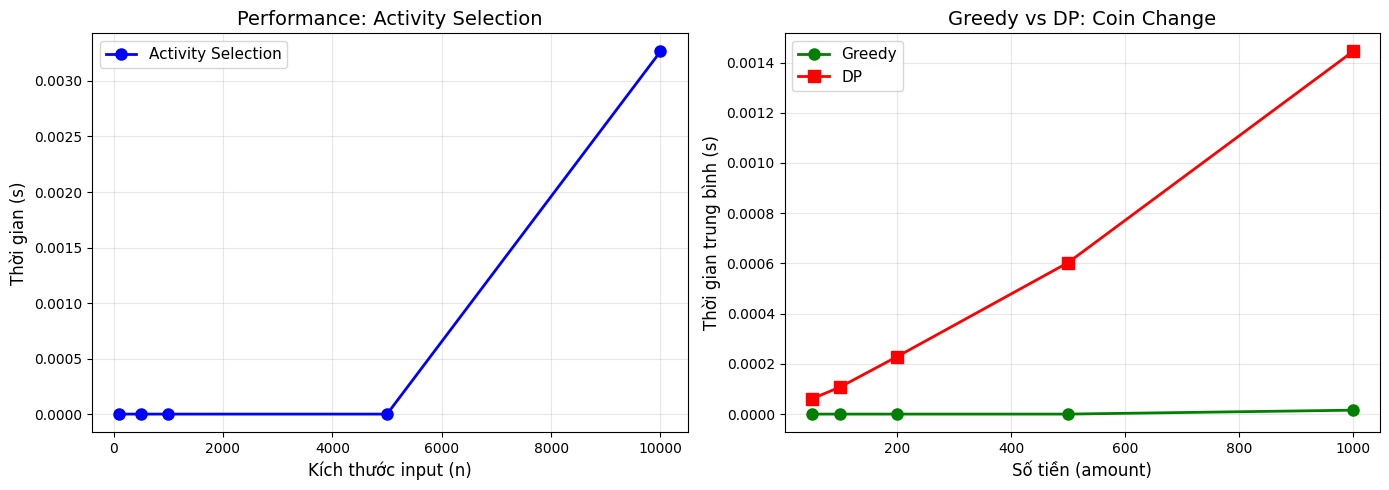

In [21]:
# Vẽ biểu đồ Performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Thời gian theo kích thước input
axes[0].plot(sizes, times, 'bo-', linewidth=2, markersize=8, label='Activity Selection')
axes[0].set_xlabel('Kích thước input (n)', fontsize=12)
axes[0].set_ylabel('Thời gian (s)', fontsize=12)
axes[0].set_title('Performance: Activity Selection', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Biểu đồ 2: So sánh Greedy vs DP cho Coin Change
amounts = [50, 100, 200, 500, 1000]
greedy_times = []
dp_times = []
coins_bench = [25, 10, 5, 1]

for amt in amounts:
    # Greedy
    start = time.time()
    for _ in range(100):  # Lặp 100 lần để đo chính xác hơn
        coin_change_greedy(amt, coins_bench[:])
    greedy_times.append((time.time() - start) / 100)
    
    # DP
    start = time.time()
    for _ in range(100):
        coin_change_dp(amt, coins_bench)
    dp_times.append((time.time() - start) / 100)

axes[1].plot(amounts, greedy_times, 'go-', linewidth=2, markersize=8, label='Greedy')
axes[1].plot(amounts, dp_times, 'rs-', linewidth=2, markersize=8, label='DP')
axes[1].set_xlabel('Số tiền (amount)', fontsize=12)
axes[1].set_ylabel('Thời gian trung bình (s)', fontsize=12)
axes[1].set_title('Greedy vs DP: Coin Change', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [26]:
print("1. Activity Selection:")
print(f"   - Với n=100:   {times[0]:.6f}s")
print(f"   - Với n=10000: {times[-1]:.6f}s")
toc_do = f"{times[-1]/times[0]:.1f}x" if times[0] > 0 else "Vô hạn (n=100 chạy quá nhanh)"
print(f"   - Tốc độ tăng: {toc_do} khi n tăng 100x")
print(f"   - Phù hợp với O(n log n)")

print("\n 2. Coin Change - Greedy vs DP:")
print(f"   - Greedy luôn nhanh hơn DP")
print(f"   - Greedy: O(n) | DP: O(amount * n)")
print(f"   - DP chậm hơn khi amount lớn")
print(f"   - Nhưng DP luôn cho kết quả đúng!")

print("\n 3. Kết luận:")
print("   - Greedy: Nhanh nhưng không luôn ok")
print("   - DP: CHẬM hơn nhưng luôn ok")
print("   - Chọn Greedy khi: biết chắc greedy đúng (canonical system)")
print("   - Chọn DP khi: cần tối ưu tuyệt đối")



1. Activity Selection:
   - Với n=100:   0.000000s
   - Với n=10000: 0.003266s
   - Tốc độ tăng: Vô hạn (n=100 chạy quá nhanh) khi n tăng 100x
   - Phù hợp với O(n log n)

 2. Coin Change - Greedy vs DP:
   - Greedy luôn nhanh hơn DP
   - Greedy: O(n) | DP: O(amount * n)
   - DP chậm hơn khi amount lớn
   - Nhưng DP luôn cho kết quả đúng!

 3. Kết luận:
   - Greedy: Nhanh nhưng không luôn ok
   - DP: CHẬM hơn nhưng luôn ok
   - Chọn Greedy khi: biết chắc greedy đúng (canonical system)
   - Chọn DP khi: cần tối ưu tuyệt đối
